# MovieLens Movie Recommendation

This example is derived from the official PyTorch Geometric [Tutorial](https://pytorch-geometric.readthedocs.io/en/latest/get_started/colabs.html).


In [76]:
import torch
from torch import Tensor

print(torch.__version__)

2.8.0+cu129


# Link Prediction on MovieLens

This colab notebook shows how to load a set of `*.csv` files as input and construct a heterogeneous graph from it.
We will then use this dataset as input into a [heterogeneous graph model](https://pytorch-geometric.readthedocs.io/en/latest/notes/heterogeneous.html#hgtutorial), and use it for the task of link prediction.
A few code cells require user input to let the code run through successfully.
If you are stuck on cells that require input, take a look at the fully filled out tutorial [here](https://medium.com/@pytorch_geometric/link-prediction-on-heterogeneous-graphs-with-pyg-6d5c29677c70).

We are going to use the [MovieLens dataset](https://grouplens.org/datasets/movielens/) collected by the GroupLens research group.
This toy dataset describes ratings and tagging activity from MovieLens.
The dataset contains approximately 100k ratings across more than 9k movies from more than 600 users.
We are going to use this dataset to generate two node types holding data for movies and users, respectively, and one edge type connecting users and movies, representing the relation of whether a user has rated a specific movie.

The link prediction task then tries to predict missing ratings, and can, for example, be used to recommend users new movies.


## Heterogeneous Graph Creation

First, we download the dataset to an arbitrary folder (in this case, the current directory):


In [77]:
from torch_geometric.data import download_url, extract_zip


folder_path = "../../model/data"
dataset_name = "ml-latest-small"

url = f"https://files.grouplens.org/datasets/movielens/{dataset_name}.zip"
extract_zip(download_url(url, folder_path), folder_path)

movies_path = f"{folder_path}/{dataset_name}/movies.csv"
ratings_path = f"{folder_path}/{dataset_name}/ratings.csv"

Using existing file ml-latest-small.zip
Extracting ../../model/data\ml-latest-small.zip


Before we create the heterogeneous graph, let’s take a look at the data.


In [78]:
import pandas as pd

print("movies.csv:")
print("===========")
print(pd.read_csv(movies_path)[["movieId", "genres"]].head())
print()
print("ratings.csv:")
print("============")
print(pd.read_csv(ratings_path)[["userId", "movieId"]].head())

movies.csv:
   movieId                                       genres
0        1  Adventure|Animation|Children|Comedy|Fantasy
1        2                   Adventure|Children|Fantasy
2        3                               Comedy|Romance
3        4                         Comedy|Drama|Romance
4        5                                       Comedy

ratings.csv:
   userId  movieId
0       1        1
1       1        3
2       1        6
3       1       47
4       1       50


We see that the `movies.csv` file provides two useful columns: `movieId` assigns a unique identifier to each movie, while the `genres` column represent genres of the given movie.
We can make use of this column to define a feature representation that can be easily interpreted by machine learning models.


In [79]:
# Load the entire movie data frame into memory:
movies_df = pd.read_csv(movies_path, index_col="movieId")

# Split genres and convert into indicator variables:
genres = movies_df["genres"].str.get_dummies("|")
print(genres[["Action", "Adventure", "Drama", "Horror"]].head())

# Use genres as movie input features:
movie_feat = torch.from_numpy(genres.values.copy()).to(torch.float)
assert movie_feat.size() == (9742, 20)  # 20 genres in total.

         Action  Adventure  Drama  Horror
movieId                                  
1             0          1      0       0
2             0          1      0       0
3             0          0      0       0
4             0          0      1       0
5             0          0      0       0


The `ratings.csv` data connects users (as given by `userId`) and movies (as given by `movieId`).
Due to simplicity, we do not make use of the additional `timestamp` and `rating` information.
Here, we first read the `*.csv` file from disk, and create a mapping that maps entry IDs to a consecutive value in the range `{ 0, ..., num_rows - 1 }`.
This is needed as we want our final data representation to be as compact as possible, _e.g._, the representation of a movie in the first row should be accessible via `x[0]`.

Afterwards, we obtain the final `edge_index` representation of shape `[2, num_ratings]` from `ratings.csv` by merging mapped user and movie indices with the raw indices given by the original data frame.


In [80]:
# Load the entire ratings data frame into memory:
ratings_df = pd.read_csv(ratings_path)

# Create a mapping from unique user indices to range [0, num_user_nodes):
unique_user_id = ratings_df["userId"].unique()
unique_user_id = pd.DataFrame(
    data={
        "userId": unique_user_id,
        "mappedID": pd.RangeIndex(len(unique_user_id)),
    }
)
print("Mapping of user IDs to consecutive values:")
print("==========================================")
print(unique_user_id.head())
print()
# Create a mapping from unique movie indices to range [0, num_movie_nodes):
unique_movie_id = pd.DataFrame(
    data={
        "movieId": movies_df.index,
        "mappedID": pd.RangeIndex(len(movies_df)),
    }
)
print("Mapping of movie IDs to consecutive values:")
print("===========================================")
print(unique_movie_id.head())

# Perform merge to obtain the edges from users and movies:
ratings_user_id = pd.merge(
    ratings_df["userId"],
    unique_user_id,
    left_on="userId",
    right_on="userId",
    how="left",
)
ratings_user_id = torch.from_numpy(ratings_user_id["mappedID"].values)
ratings_movie_id = pd.merge(
    ratings_df["movieId"],
    unique_movie_id,
    left_on="movieId",
    right_on="movieId",
    how="left",
)
ratings_movie_id = torch.from_numpy(ratings_movie_id["mappedID"].values)

# With this, we are ready to construct our `edge_index` in COO format
# following PyG semantics:
edge_index_user_to_movie = torch.stack([ratings_user_id, ratings_movie_id], dim=0)
assert edge_index_user_to_movie.size() == (2, 100836)

print()
print("Final edge indices pointing from users to movies:")
print("=================================================")
print(edge_index_user_to_movie)

Mapping of user IDs to consecutive values:
   userId  mappedID
0       1         0
1       2         1
2       3         2
3       4         3
4       5         4

Mapping of movie IDs to consecutive values:
   movieId  mappedID
0        1         0
1        2         1
2        3         2
3        4         3
4        5         4

Final edge indices pointing from users to movies:
tensor([[   0,    0,    0,  ...,  609,  609,  609],
        [   0,    2,    5,  ..., 9462, 9463, 9503]])


With this, we are ready to initialize our `HeteroData` object and pass the necessary information to it.
Note that we also pass in a `node_id` vector to each node type in order to reconstruct the original node indices from sampled subgraphs.
We also take care of adding reverse edges to the `HeteroData` object.
This allows our GNN model to use both directions of the edge for message passing:


In [81]:
from torch_geometric.data import HeteroData
import torch_geometric.transforms as T

data = HeteroData()

# Save node indices:
data["user"].node_id = torch.arange(len(unique_user_id))
data["movie"].node_id = torch.arange(len(movies_df))

# Add the node features and edge indices:
data["movie"].x = movie_feat
data["user", "rates", "movie"].edge_index = torch.stack(
    [ratings_user_id, ratings_movie_id], dim=0
)

# We also need to make sure to add the reverse edges from movies to users
# in order to let a GNN be able to pass messages in both directions.
# We can leverage the `T.ToUndirected()` transform for this from PyG:

data = T.ToUndirected()(data)

print(data)

assert data.node_types == ["user", "movie"]
assert data.edge_types == [("user", "rates", "movie"), ("movie", "rev_rates", "user")]
assert data["user"].num_nodes == 610
assert data["user"].num_features == 0
assert data["movie"].num_nodes == 9742
assert data["movie"].num_features == 20
assert data["user", "rates", "movie"].num_edges == 100836
assert data["movie", "rev_rates", "user"].num_edges == 100836

HeteroData(
  user={ node_id=[610] },
  movie={
    node_id=[9742],
    x=[9742, 20],
  },
  (user, rates, movie)={ edge_index=[2, 100836] },
  (movie, rev_rates, user)={ edge_index=[2, 100836] }
)


## Defining Edge-level Training Splits

Since our data is now ready-to-be-used, we can split the ratings of users into training, validation, and test splits.
This is needed in order to ensure that we leak no information about edges used during evaluation into the training phase.
For this, we make use of the [`transforms.RandomLinkSplit`](https://pytorch-geometric.readthedocs.io/en/latest/modules/transforms.html#torch_geometric.transforms.RandomLinkSplit) transformation from PyG.
This transforms randomly divides the edges in the `("user", "rates", "movie")` into training, validation and test edges.
The `disjoint_train_ratio` parameter further separates edges in the training split into edges used for message passing (`edge_index`) and edges used for supervision (`edge_label_index`).
Note that we also need to specify the reverse edge type `("movie", "rev_rates", "user")`.
This allows the `RandomLinkSplit` transform to drop reverse edges accordingly to not leak any information into the training phase.


In [82]:
# For this, we first split the set of edges into
# training (80%), validation (10%), and testing edges (10%).
# Across the training edges, we use 70% of edges for message passing,
# and 30% of edges for supervision.
# We further want to generate fixed negative edges for evaluation with a ratio of 2:1.
# Negative edges during training will be generated on-the-fly, so we don't want to
# add them to the graph right away.
# Overall, we can leverage the `RandomLinkSplit()` transform for this from PyG:
transform = T.RandomLinkSplit(
    num_val=0.1,
    num_test=0.1,
    disjoint_train_ratio=0.3,
    neg_sampling_ratio=2.0,
    add_negative_train_samples=False,
    edge_types=("user", "rates", "movie"),
    rev_edge_types=("movie", "rev_rates", "user"),
)

train_data, val_data, test_data = transform(data)
print("Training data:")
print("==============")
print(train_data)
print()
print("Validation data:")
print("================")
print(val_data)

assert train_data["user", "rates", "movie"].num_edges == 56469
assert train_data["user", "rates", "movie"].edge_label_index.size(1) == 24201
assert train_data["movie", "rev_rates", "user"].num_edges == 56469
# No negative edges added:
assert train_data["user", "rates", "movie"].edge_label.min() == 1
assert train_data["user", "rates", "movie"].edge_label.max() == 1

assert val_data["user", "rates", "movie"].num_edges == 80670
assert val_data["user", "rates", "movie"].edge_label_index.size(1) == 30249
assert val_data["movie", "rev_rates", "user"].num_edges == 80670
# Negative edges with ratio 2:1:
assert val_data["user", "rates", "movie"].edge_label.long().bincount().tolist() == [
    20166,
    10083,
]

Training data:
HeteroData(
  user={ node_id=[610] },
  movie={
    node_id=[9742],
    x=[9742, 20],
  },
  (user, rates, movie)={
    edge_index=[2, 56469],
    edge_label=[24201],
    edge_label_index=[2, 24201],
  },
  (movie, rev_rates, user)={ edge_index=[2, 56469] }
)

Validation data:
HeteroData(
  user={ node_id=[610] },
  movie={
    node_id=[9742],
    x=[9742, 20],
  },
  (user, rates, movie)={
    edge_index=[2, 80670],
    edge_label=[30249],
    edge_label_index=[2, 30249],
  },
  (movie, rev_rates, user)={ edge_index=[2, 80670] }
)


## Defining Mini-batch Loaders

We are now ready to create a mini-batch loader that will generate subgraphs that can be used as input into our GNN.
While this step is not strictly necessary for small-scale graphs, it is absolutely necessary to apply GNNs on larger graphs that do not fit onto GPU memory otherwise.
Here, we make use of the [`loader.LinkNeighborLoader`](https://pytorch-geometric.readthedocs.io/en/latest/modules/loader.html#torch_geometric.loader.LinkNeighborLoader) which samples multiple hops from both ends of a link and creates a subgraph from it.
Here, `edge_label_index` serves as the "seed links" to start sampling from.


In [83]:
# In the first hop, we sample at most 20 neighbors.
# In the second hop, we sample at most 10 neighbors.
# In addition, during training, we want to sample negative edges on-the-fly with
# a ratio of 2:1.
# We can make use of the `loader.LinkNeighborLoader` from PyG:
from torch_geometric.loader import LinkNeighborLoader

# Define seed edges:
edge_label_index = train_data["user", "rates", "movie"].edge_label_index
edge_label = train_data["user", "rates", "movie"].edge_label

train_loader = LinkNeighborLoader(
    data=train_data,
    num_neighbors=[20, 10],
    neg_sampling_ratio=2.0,
    edge_label_index=(("user", "rates", "movie"), edge_label_index),
    edge_label=edge_label,
    batch_size=128,
    shuffle=True,
)

# Inspect a sample:
sampled_data = next(iter(train_loader))

print("Sampled mini-batch:")
print("===================")
print(sampled_data)

assert sampled_data["user", "rates", "movie"].edge_label_index.size(1) == 3 * 128
assert sampled_data["user", "rates", "movie"].edge_label.min() == 0
assert sampled_data["user", "rates", "movie"].edge_label.max() == 1

Sampled mini-batch:
HeteroData(
  user={
    node_id=[608],
    n_id=[608],
  },
  movie={
    node_id=[2758],
    x=[2758, 20],
    n_id=[2758],
  },
  (user, rates, movie)={
    edge_index=[2, 17369],
    edge_label=[384],
    edge_label_index=[2, 384],
    e_id=[17369],
    input_id=[128],
  },
  (movie, rev_rates, user)={
    edge_index=[2, 7763],
    e_id=[7763],
  }
)


## Creating a Heterogeneous Link-level GNN

We are now ready to create our heterogeneous GNN.
The GNN is responsible for learning enriched node representations from the surrounding subgraphs, which can be then used to derive edge-level predictions.
For defining our heterogenous GNN, we make use of [`nn.SAGEConv`](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#torch_geometric.nn.conv.SAGEConv) and the [`nn.to_hetero()`](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#torch_geometric.nn.to_hetero_transformer.to_hetero) function, which transforms a GNN defined on homogeneous graphs to be applied on heterogeneous ones.

In addition, we define a final link-level classifier, which simply takes both node embeddings of the link we are trying to predict, and applies a dot-product on them.

As users do not have any node-level information, we choose to learn their features jointly via a `torch.nn.Embedding` layer. In order to improve the expressiveness of movie features, we do the same for movie nodes, and simply add their shallow embeddings to the pre-defined genre features.


In [84]:
from torch_geometric.nn import SAGEConv, to_hetero
from torch.nn import functional as F


class GNN(torch.nn.Module):
    def __init__(self, hidden_channels, dropout=0.5):
        super().__init__()
        self.conv1 = SAGEConv(hidden_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.dropout = torch.nn.Dropout(p=dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x


# Our final classifier applies the dot-product between source and destination
# node embeddings to derive edge-level predictions:
class Classifier(torch.nn.Module):
    def forward(
        self, x_user: Tensor, x_movie: Tensor, edge_label_index: Tensor
    ) -> Tensor:
        # Convert node embeddings to edge-level representations:
        edge_feat_user = x_user[edge_label_index[0]]
        edge_feat_movie = x_movie[edge_label_index[1]]

        # Apply dot-product to get a prediction per supervision edge:
        return (edge_feat_user * edge_feat_movie).sum(dim=-1)


class Model(torch.nn.Module):
    def __init__(self, hidden_channels, dropout=0.5):
        super().__init__()
        self.movie_lin = torch.nn.Linear(20, hidden_channels)
        self.user_emb = torch.nn.Embedding(data["user"].num_nodes, hidden_channels)
        self.movie_emb = torch.nn.Embedding(data["movie"].num_nodes, hidden_channels)
        self.input_dropout = torch.nn.Dropout(p=dropout)

        self.gnn = GNN(hidden_channels, dropout=dropout)
        self.gnn = to_hetero(self.gnn, metadata=data.metadata())
        self.classifier = Classifier()

    def forward(self, data):
        user_x = self.user_emb(data["user"].node_id)
        movie_x = self.movie_lin(data["movie"].x) + self.movie_emb(
            data["movie"].node_id
        )

        user_x = self.input_dropout(user_x)
        movie_x = self.input_dropout(movie_x)

        x_dict = {
            "user": user_x,
            "movie": movie_x,
        }

        x_dict = self.gnn(x_dict, data.edge_index_dict)

        pred = self.classifier(
            x_dict["user"],
            x_dict["movie"],
            data["user", "rates", "movie"].edge_label_index,
        )
        return pred

## Training a Heterogeneous Link-level GNN

Training our GNN is then similar to training any PyTorch model.
We move the model to the desired device, and initialize an optimizer that takes care of adjusting model parameters via stochastic gradient descent.

The training loop then iterates over our mini-batches, applies the forward computation of the model, computes the loss from ground-truth labels and obtained predictions (here we make use of binary cross entropy), and adjusts model parameters via back-propagation and stochastic gradient descent.


In [85]:
from dotenv import load_dotenv

load_dotenv("../.env")

True

In [86]:
import os

print("WANDB_API_KEY present:", bool(os.getenv("WANDB_API_KEY")))
print("WANDB_PROJECT:", os.getenv("WANDB_PROJECT"))
print("WANDB_ENTITY:", os.getenv("WANDB_ENTITY"))
# print("WANDB__SERVICE_WAIT:", os.getenv("WANDB__SERVICE_WAIT"))

WANDB_API_KEY present: True
WANDB_PROJECT: movie-rec-pyg
WANDB_ENTITY: pedro-stark-ai


In [87]:
from dotenv import load_dotenv

load_dotenv("../.env")

True

In [88]:
# Init dotenv for wanbd

from datetime import datetime

import wandb


config = {
    "hidden_channels": 128,
    "dropout": 0.5,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "epochs": 2,
    "use_wandb": False,
}

run_name = f"sage-h{config['hidden_channels']}-lr{config['lr']}-wd{config['weight_decay']}-{datetime.now().strftime('%Y%m%d-%H%M%S')}"

if config["use_wandb"]:
    wandb.init(name=run_name, config=config)

In [89]:
model = Model(hidden_channels=config["hidden_channels"], dropout=config["dropout"])

print(model)

Model(
  (movie_lin): Linear(in_features=20, out_features=128, bias=True)
  (user_emb): Embedding(610, 128)
  (movie_emb): Embedding(9742, 128)
  (input_dropout): Dropout(p=0.5, inplace=False)
  (gnn): GraphModule(
    (conv1): ModuleDict(
      (user__rates__movie): SAGEConv(128, 128, aggr=mean)
      (movie__rev_rates__user): SAGEConv(128, 128, aggr=mean)
    )
    (dropout): ModuleDict(
      (user): Dropout(p=0.5, inplace=False)
      (movie): Dropout(p=0.5, inplace=False)
    )
    (conv2): ModuleDict(
      (user__rates__movie): SAGEConv(128, 128, aggr=mean)
      (movie__rev_rates__user): SAGEConv(128, 128, aggr=mean)
    )
  )
  (classifier): Classifier()
)


In [90]:
import tqdm
import torch
import torch.nn.functional as F
import wandb

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: '{device}'")

model = model.to(device)
optimizer = torch.optim.Adam(
    model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"]
)

# Log gradients and parameter statistics.
# Useful, but can add overhead for large models.
if config["use_wandb"]:
    wandb.watch(model, log="all", log_freq=100)

# Build validation loader once so we can compute validation metrics every epoch.
val_edge_label_index = val_data["user", "rates", "movie"].edge_label_index
val_edge_label = val_data["user", "rates", "movie"].edge_label
val_loader = LinkNeighborLoader(
    data=val_data,
    num_neighbors=[20, 10],
    edge_label_index=(("user", "rates", "movie"), val_edge_label_index),
    edge_label=val_edge_label,
    batch_size=3 * 128,
    shuffle=False,
)

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

global_step = 0

for epoch in range(1, config["epochs"] + 1):
    # Training
    model.train()
    train_total_loss = 0.0
    train_total_examples = 0
    train_correct = 0

    for sampled_data in tqdm.tqdm(train_loader, desc=f"Epoch {epoch:03d} [train]"):
        optimizer.zero_grad()
        sampled_data = sampled_data.to(device)

        pred = model(sampled_data)
        ground_truth = sampled_data["user", "rates", "movie"].edge_label.float()

        loss = F.binary_cross_entropy_with_logits(pred, ground_truth)
        loss.backward()
        optimizer.step()

        batch_size = pred.numel()
        train_total_loss += float(loss.detach()) * batch_size
        train_total_examples += batch_size

        train_pred_labels = (torch.sigmoid(pred) >= 0.5).float()
        train_correct += int((train_pred_labels == ground_truth).sum().item())

        global_step += 1

        if config["use_wandb"]:
            wandb.log(
                {
                    "batch/train_loss": float(loss.detach()),
                    "batch/step": global_step,
                    "epoch": epoch,
                },
                step=global_step,
            )

    train_loss = train_total_loss / train_total_examples
    train_acc = train_correct / train_total_examples
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validation
    model.eval()
    val_total_loss = 0.0
    val_total_examples = 0
    val_correct = 0

    with torch.no_grad():
        for sampled_data in val_loader:
            sampled_data = sampled_data.to(device)

            pred = model(sampled_data)
            ground_truth = sampled_data["user", "rates", "movie"].edge_label.float()

            loss = F.binary_cross_entropy_with_logits(pred, ground_truth)

            batch_size = pred.numel()
            val_total_loss += float(loss.detach()) * batch_size
            val_total_examples += batch_size

            val_pred_labels = (torch.sigmoid(pred) >= 0.5).float()
            val_correct += int((val_pred_labels == ground_truth).sum().item())

    val_loss = val_total_loss / val_total_examples
    val_acc = val_correct / val_total_examples
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch: {epoch:03d}, "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

    # Epoch-level logging
    if config["use_wandb"]:
        wandb.log(
            {
                "epoch": epoch,
                "train/loss": train_loss,
                "train/accuracy": train_acc,
                "val/loss": val_loss,
                "val/accuracy": val_acc,
                "lr": optimizer.param_groups[0]["lr"],
            },
            step=global_step,
        )

print("\nFinal metrics:")
print(f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracies[-1]:.4f}")
print(f"Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accuracies[-1]:.4f}")

# Store final values in the run summary for quick access in W&B UI
if config["use_wandb"]:
    wandb.summary["final_train_loss"] = train_losses[-1]
    wandb.summary["final_train_accuracy"] = train_accuracies[-1]
    wandb.summary["final_val_loss"] = val_losses[-1]
    wandb.summary["final_val_accuracy"] = val_accuracies[-1]

    wandb.finish()

Device: 'cuda'


Epoch 001 [train]: 100%|██████████| 190/190 [00:10<00:00, 18.85it/s]


Epoch: 001, Train Loss: 0.7022, Train Acc: 0.6745, Val Loss: 0.5138, Val Acc: 0.7633


Epoch 002 [train]: 100%|██████████| 190/190 [00:11<00:00, 16.34it/s]


Epoch: 002, Train Loss: 0.4875, Train Acc: 0.7584, Val Loss: 0.4494, Val Acc: 0.7897

Final metrics:
Train Loss: 0.4875, Train Acc: 0.7584
Val Loss: 0.4494, Val Acc: 0.7897


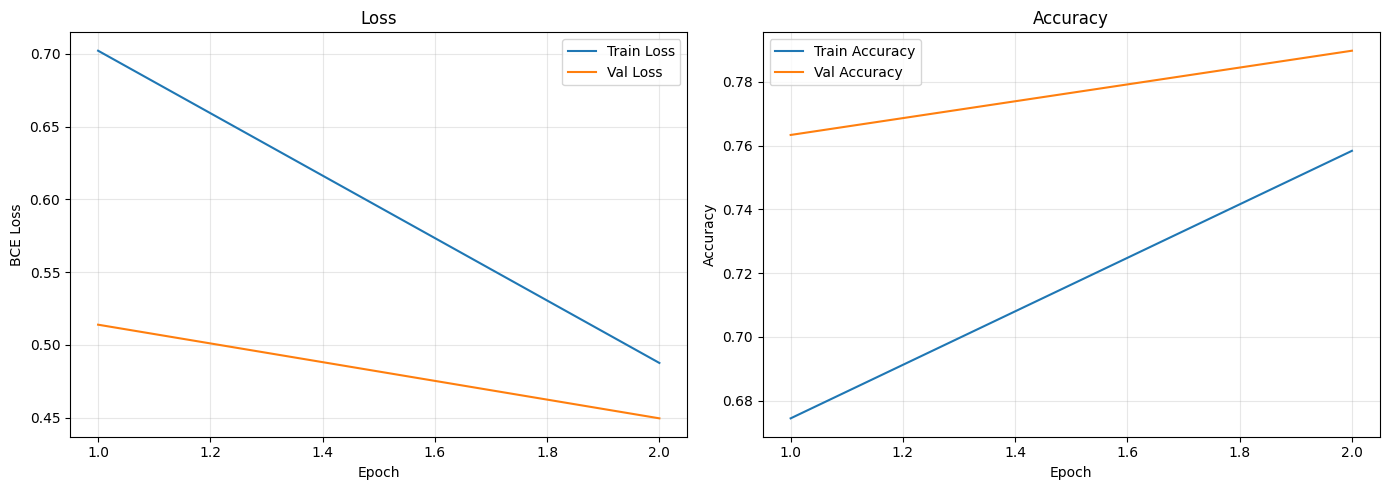

In [91]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, train_losses, label="Train Loss")
axes[0].plot(epochs, val_losses, label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, train_accuracies, label="Train Accuracy")
axes[1].plot(epochs, val_accuracies, label="Val Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluating a Heterogeneous Link-level GNN

After training, we evaluate our model on useen data coming from the validation set.
For this, we define a new `LinkNeighborLoader` (which now iterates over the edges in the validation set), obtain the predictions on validation edges by running the model, and finally evaluate the performance of the model by computing the AUC score over the set of predictions and their corresponding ground-truth edges (including both positive and negative edges).


In [92]:
# Define the validation seed edges:
edge_label_index = val_data["user", "rates", "movie"].edge_label_index
edge_label = val_data["user", "rates", "movie"].edge_label

val_loader = LinkNeighborLoader(
    data=val_data,
    num_neighbors=[20, 10],
    edge_label_index=(("user", "rates", "movie"), edge_label_index),
    edge_label=edge_label,
    batch_size=3 * 128,
    shuffle=False,
)

sampled_data = next(iter(val_loader))

print("Sampled mini-batch:")
print("===================")
print(sampled_data)

assert sampled_data["user", "rates", "movie"].edge_label_index.size(1) == 3 * 128
assert sampled_data["user", "rates", "movie"].edge_label.min() >= 0
assert sampled_data["user", "rates", "movie"].edge_label.max() <= 1

Sampled mini-batch:
HeteroData(
  user={
    node_id=[603],
    n_id=[603],
  },
  movie={
    node_id=[2702],
    x=[2702, 20],
    n_id=[2702],
  },
  (user, rates, movie)={
    edge_index=[2, 19249],
    edge_label=[384],
    edge_label_index=[2, 384],
    e_id=[19249],
    input_id=[384],
  },
  (movie, rev_rates, user)={
    edge_index=[2, 7741],
    e_id=[7741],
  }
)


In [93]:
import tqdm
from sklearn.metrics import roc_auc_score

preds = []
ground_truths = []
for sampled_data in tqdm.tqdm(val_loader):
    with torch.no_grad():
        sampled_data = sampled_data.to(device)
        model.eval()
        pred = model(sampled_data)
        ground_truth = sampled_data["user", "rates", "movie"].edge_label
        preds.append(pred)
        ground_truths.append(ground_truth)

pred = torch.cat(preds, dim=0).cpu().numpy()
ground_truth = torch.cat(ground_truths, dim=0).cpu().numpy()
auc = roc_auc_score(ground_truth, pred)
print()
print(f"Validation AUC: {auc:.4f}")

100%|██████████| 79/79 [00:04<00:00, 19.43it/s]


Validation AUC: 0.8974


## Exporting the Trained Model to ONNX

The trained PyTorch model expects a `HeteroData` object as input, so we wrap it in a thin adapter that receives plain tensors. This makes the graph exportable to ONNX and easy to replay with ONNX Runtime.


In [94]:
import copy
from pathlib import Path

import numpy as np
import onnx
import onnxruntime as ort


class ONNXLinkPredictionWrapper(torch.nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(
        self,
        user_node_id,
        movie_node_id,
        movie_x,
        rates_edge_index,
        rev_rates_edge_index,
        edge_label_index,
    ):
        user_x = self.base_model.user_emb(user_node_id)
        movie_x = self.base_model.movie_lin(movie_x) + self.base_model.movie_emb(
            movie_node_id
        )

        x_dict = {
            "user": user_x,
            "movie": movie_x,
        }
        edge_index_dict = {
            ("user", "rates", "movie"): rates_edge_index,
            ("movie", "rev_rates", "user"): rev_rates_edge_index,
        }

        x_dict = self.base_model.gnn(x_dict, edge_index_dict)
        return self.base_model.classifier(
            x_dict["user"],
            x_dict["movie"],
            edge_label_index,
        )


onnx_dir = Path("artifacts")
onnx_dir.mkdir(parents=True, exist_ok=True)
onnx_path = onnx_dir / "graph_link_prediction.onnx"

model_cpu = copy.deepcopy(model).to("cpu").eval()
onnx_model = ONNXLinkPredictionWrapper(model_cpu).eval()
sampled_data_cpu = sampled_data.to("cpu")

onnx_inputs = (
    sampled_data_cpu["user"].node_id.long(),
    sampled_data_cpu["movie"].node_id.long(),
    sampled_data_cpu["movie"].x.float(),
    sampled_data_cpu["user", "rates", "movie"].edge_index.long(),
    sampled_data_cpu["movie", "rev_rates", "user"].edge_index.long(),
    sampled_data_cpu["user", "rates", "movie"].edge_label_index.long(),
)

input_names = [
    "user_node_id",
    "movie_node_id",
    "movie_x",
    "rates_edge_index",
    "rev_rates_edge_index",
    "edge_label_index",
]

dynamic_axes = {
    "user_node_id": {0: "num_user_nodes"},
    "movie_node_id": {0: "num_movie_nodes"},
    "movie_x": {0: "num_movie_nodes"},
    "rates_edge_index": {1: "num_rate_edges"},
    "rev_rates_edge_index": {1: "num_rev_rate_edges"},
    "edge_label_index": {1: "num_edge_labels"},
    "logits": {0: "num_edge_labels"},
}

torch.onnx.export(
    onnx_model,
    onnx_inputs,
    onnx_path.as_posix(),
    input_names=input_names,
    output_names=["logits"],
    dynamic_axes=dynamic_axes,
    opset_version=17,
)

onnx.checker.check_model(onnx.load(onnx_path))
print(f"Exported ONNX model to: {onnx_path.resolve()}")

C:\Users\pedro\AppData\Local\Temp\ipykernel_18232\1239141497.py:81: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


Exported ONNX model to: C:\GithubDesktopRepos\tsm_mach_le_data\training\poc\artifacts\graph_link_prediction.onnx


In [95]:
torch_inputs = {
    "user_node_id": onnx_inputs[0],
    "movie_node_id": onnx_inputs[1],
    "movie_x": onnx_inputs[2],
    "rates_edge_index": onnx_inputs[3],
    "rev_rates_edge_index": onnx_inputs[4],
    "edge_label_index": onnx_inputs[5],
}

with torch.no_grad():
    torch_logits = onnx_model(*onnx_inputs).cpu().numpy()

session = ort.InferenceSession(onnx_path.as_posix(), providers=["CPUExecutionProvider"])
ort_inputs = {name: tensor.cpu().numpy() for name, tensor in torch_inputs.items()}
ort_logits = session.run(["logits"], ort_inputs)[0]

max_abs_diff = np.max(np.abs(torch_logits - ort_logits))
print(f"PyTorch logits shape: {torch_logits.shape}")
print(f"ONNX logits shape:    {ort_logits.shape}")
print(f"Max abs diff:         {max_abs_diff:.6f}")

np.testing.assert_allclose(torch_logits, ort_logits, rtol=1e-4, atol=1e-4)
print("ONNX reload inference matches PyTorch within tolerance.")

PyTorch logits shape: (297,)
ONNX logits shape:    (297,)
Max abs diff:         0.000001
ONNX reload inference matches PyTorch within tolerance.


## Example Recommendation Prediction

A recommendation model is only useful if we can rank movies a user has not seen yet. The example below scores all unseen movies for one user and prints the top recommendations.


In [ ]:
from torch_geometric.data import HeteroData

example_user_id = 1
top_k = 10

mapped_user_id = int(
    unique_user_id.loc[unique_user_id["userId"] == example_user_id, "mappedID"].iloc[0]
)

seen_movie_ids = set(ratings_df.loc[ratings_df["userId"] == example_user_id, "movieId"])
candidate_movies = unique_movie_id.loc[
    ~unique_movie_id["movieId"].isin(seen_movie_ids)
].copy()
candidate_movies["title"] = candidate_movies["movieId"].map(movies_df["title"])

recommendation_data = HeteroData()
recommendation_data["user"].node_id = data["user"].node_id.clone()
recommendation_data["movie"].node_id = data["movie"].node_id.clone()
recommendation_data["movie"].x = data["movie"].x.clone()
recommendation_data["user", "rates", "movie"].edge_index = data[
    "user", "rates", "movie"
].edge_index.clone()
recommendation_data["movie", "rev_rates", "user"].edge_index = data[
    "movie", "rev_rates", "user"
].edge_index.clone()
recommendation_data["user", "rates", "movie"].edge_label_index = torch.stack(
    [
        torch.full((len(candidate_movies),), mapped_user_id, dtype=torch.long),
        torch.tensor(candidate_movies["mappedID"].to_numpy(), dtype=torch.long),
    ],
    dim=0,
)

model.eval()
with torch.no_grad():
    logits = model(recommendation_data.to(device))
    scores = torch.sigmoid(logits).cpu().numpy()

recommendations = candidate_movies[["movieId", "title"]].copy()
recommendations["score"] = scores
recommendations = recommendations.sort_values("score", ascending=False).head(top_k)

print(f"Top {top_k} recommendations for user {example_user_id}:")
recommendations.reset_index(drop=True)

Top 10 recommendations for user 1:


,movieId,title,score
0,292,Outbreak (1995),0.583741
1,95,Broken Arrow (1996),0.580397
2,153,Batman Forever (1995),0.574857
3,10,GoldenEye (1995),0.572411
4,112,Rumble in the Bronx (Hont faan kui) (1995),0.570624
5,1356,Star Trek: First Contact (1996),0.569560
6,315,"Specialist, The (1994)",0.567441
7,364,"Lion King, The (1994)",0.563491
8,31184,Appleseed (Appurushîdo) (2004),0.563418
9,165,Die Hard: With a Vengeance (1995),0.562958
